In [27]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
mat = scipy.io.loadmat("../data/raw/B0005.mat")

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'B0005'])


In [7]:
battery = mat['B0005']

print(type(battery))
print(battery.shape)

<class 'numpy.ndarray'>
(1, 1)


In [8]:
cycles = battery[0, 0]['cycle'][0]

print("Number of cycles:", len(cycles))

Number of cycles: 616


In [9]:
cycle = cycles[0]

print(cycle.dtype)

[('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')]


In [14]:
discharge_cycles = []

for cycle in cycles:
    cycle_type = cycle['type'][0]

    if cycle_type == 'discharge':
        discharge_cycles.append(cycle)

print("Discharge cycles:", len(discharge_cycles))

Discharge cycles: 168


In [16]:
capacities = []

for cycle in discharge_cycles:
    capacity = cycle['data'][0,0]['Capacity'][0,0]
    capacities.append(capacity)

capacities[:10]

[np.float64(1.8564874208181574),
 np.float64(1.846327249719927),
 np.float64(1.8353491942234077),
 np.float64(1.8352625275821128),
 np.float64(1.8346455082120419),
 np.float64(1.8356616600675495),
 np.float64(1.8351461429226603),
 np.float64(1.8257567905665537),
 np.float64(1.8247738529891333),
 np.float64(1.824613268496936)]

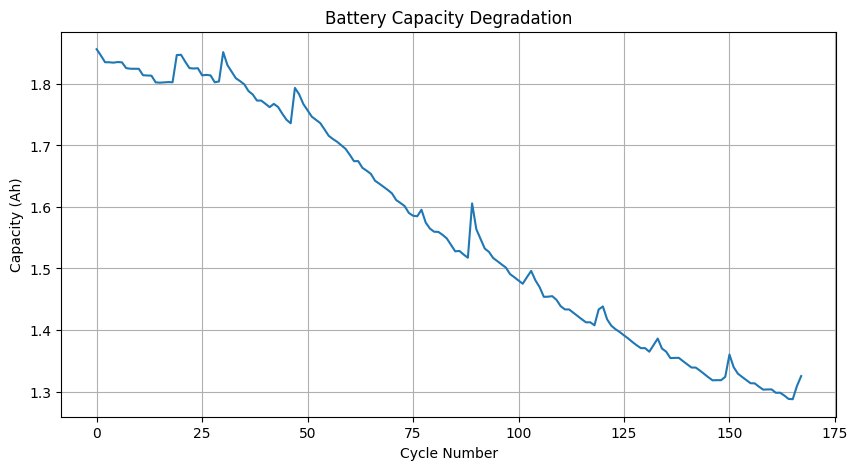

In [17]:
plt.figure(figsize=(10,5))

plt.plot(capacities)

plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.title("Battery Capacity Degradation")

plt.grid(True)

plt.show()

In [19]:
initial_capacity = capacities[0]

soh = [(c / initial_capacity) * 100 for c in capacities]

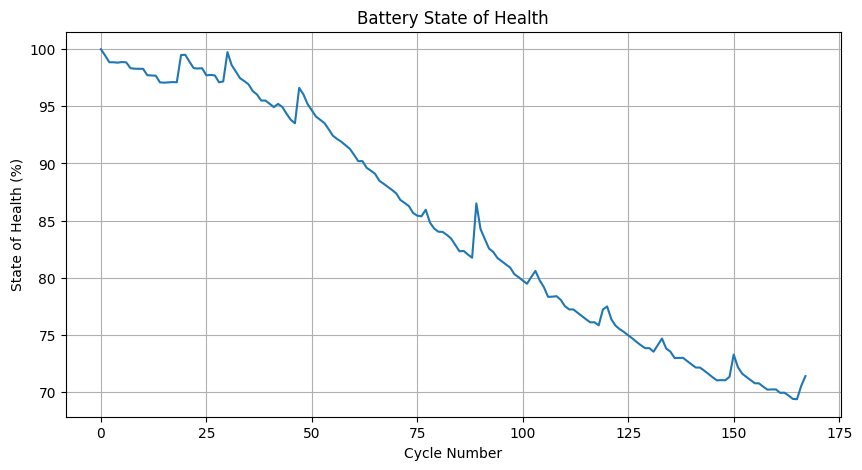

In [20]:
plt.figure(figsize=(10,5))

plt.plot(soh)

plt.xlabel("Cycle Number")
plt.ylabel("State of Health (%)")
plt.title("Battery State of Health")

plt.grid(True)

plt.show()

In [21]:
features = []

for i, cycle in enumerate(discharge_cycles):

    data = cycle['data'][0,0]

    voltage = data['Voltage_measured'][0]
    current = data['Current_measured'][0]
    temperature = data['Temperature_measured'][0]
    time = data['Time'][0]

    capacity = data['Capacity'][0,0]

    feature_dict = {
        'cycle': i,
        'capacity': capacity,
        'soh': (capacity / capacities[0]) * 100,

        'avg_voltage': np.mean(voltage),
        'max_voltage': np.max(voltage),
        'min_voltage': np.min(voltage),

        'avg_current': np.mean(current),

        'avg_temp': np.mean(temperature),
        'max_temp': np.max(temperature),

        'discharge_time': len(time)
    }

    features.append(feature_dict)

In [22]:
feature_df = pd.DataFrame(features)

feature_df.head()

,cycle,capacity,soh,avg_voltage,max_voltage,min_voltage,avg_current,avg_temp,max_temp,discharge_time
0,0,1.856487,100.000000,3.529829,4.191492,2.612467,-1.818702,32.572328,38.982181,197
1,1,1.846327,99.452721,3.537320,4.189773,2.587209,-1.817560,32.725235,39.033398,196
2,2,1.835349,98.861386,3.543737,4.188187,2.651917,-1.816487,32.642862,38.818797,195
3,3,1.835263,98.856718,3.543666,4.188461,2.592948,-1.825589,32.514876,38.762305,194
4,4,1.834646,98.823482,3.542343,4.188299,2.547420,-1.826114,32.382349,38.665393,194


In [23]:
corr = feature_df.corr(numeric_only=True)

corr['soh'].sort_values(ascending=False)

capacity          1.000000
soh               1.000000
avg_voltage       0.982357
max_voltage      -0.222038
discharge_time   -0.342844
min_voltage      -0.487071
avg_temp         -0.809744
avg_current      -0.933321
max_temp         -0.935272
cycle            -0.987739
Name: soh, dtype: float64

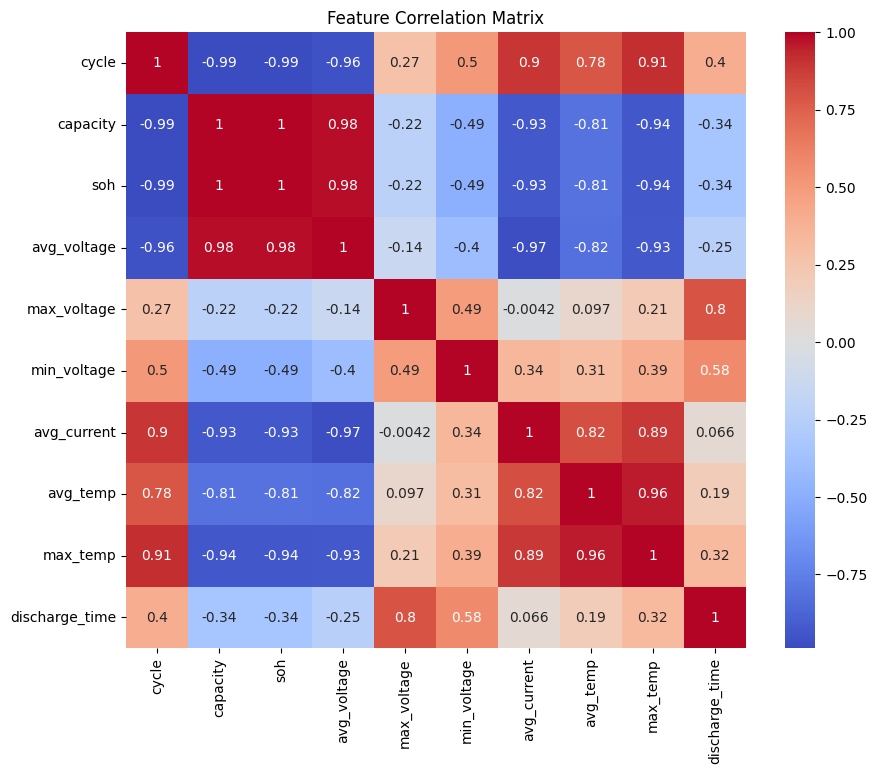

In [24]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

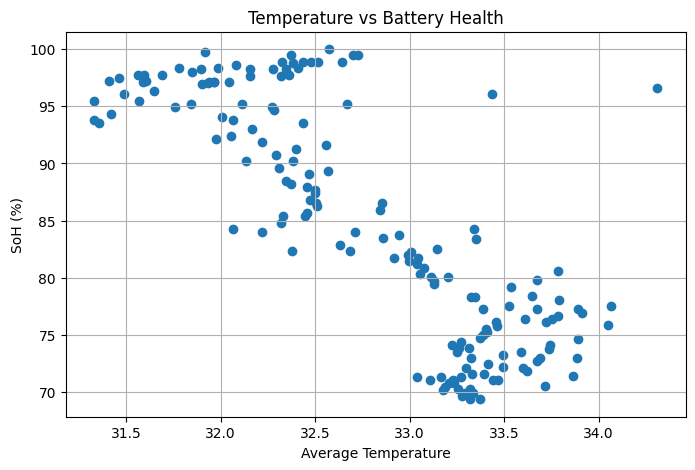

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(feature_df['avg_temp'], feature_df['soh'])

plt.xlabel("Average Temperature")
plt.ylabel("SoH (%)")
plt.title("Temperature vs Battery Health")

plt.grid(True)

plt.show()

In [26]:
feature_df.to_csv("../data/processed/battery_features.csv", index=False)

In [28]:
from sklearn.model_selection import train_test_split

In [31]:
X = feature_df[
    [
        'avg_voltage',
        'max_voltage',
        'min_voltage',
        'avg_current',
        'avg_temp',
        'max_temp',
        'discharge_time'
    ]
]

y = feature_df['soh']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(134, 7)
(34, 7)


In [37]:
from xgboost import XGBRegressor

In [38]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [42]:
y_pred = model.predict(X_test)
print(y_pred)

[73.240204 96.494675 77.209366 97.225494 72.05492  69.88957  69.45391
 94.47816  79.451416 91.53182  97.39927  70.90777  75.2325   94.39571
 88.3173   82.245575 97.74082  78.29102  84.77337  78.292274 98.43693
 97.56656  97.963715 97.07708  97.63254  98.258156 83.308266 80.88805
 84.233574 93.41223  95.38978  93.52907  70.97862  77.47185 ]


In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [44]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.4736
RMSE: 0.7642
R² Score: 0.9945


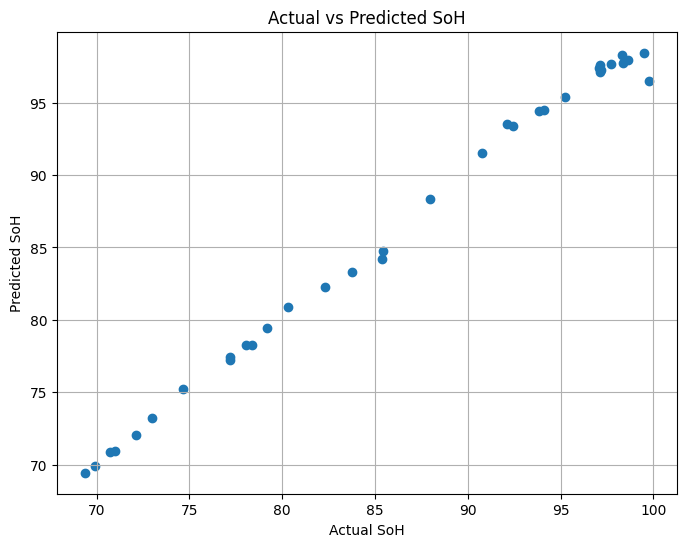

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual SoH")
plt.ylabel("Predicted SoH")

plt.title("Actual vs Predicted SoH")

plt.grid(True)

plt.show()

In [57]:
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

feature_importance_df

,feature,importance
0,avg_voltage,0.731756
5,max_temp,0.179688
3,avg_current,0.079066
1,max_voltage,0.004854
6,discharge_time,0.003545
4,avg_temp,0.000630
2,min_voltage,0.000462


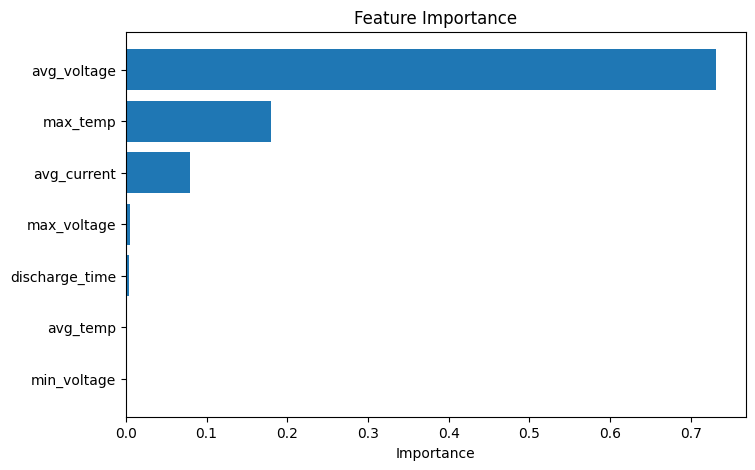

In [58]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance_df['feature'],
    feature_importance_df['importance']
)

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [64]:
import joblib

joblib.dump(model, "../models/xgboost_soh_model.pkl")

['../models/xgboost_soh_model.pkl']

In [63]:
import os

os.makedirs("../models", exist_ok=True)

In [65]:
from sklearn.ensemble import IsolationForest

In [66]:
anomaly_features = feature_df[
    [
        'avg_voltage',
        'avg_current',
        'avg_temp',
        'max_temp',
        'discharge_time',
        'capacity'
    ]
]

In [69]:
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_model.fit(anomaly_features)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [70]:
feature_df['anomaly'] = iso_model.predict(anomaly_features)

In [74]:
feature_df['anomaly'].value_counts()

anomaly
 1    159
-1      9
Name: count, dtype: int64

In [75]:
anomalies = feature_df[feature_df['anomaly'] == -1]

anomalies.head()

,cycle,capacity,soh,avg_voltage,max_voltage,min_voltage,avg_current,avg_temp,max_temp,discharge_time,anomaly
0,0,1.856487,100.000000,3.529829,4.191492,2.612467,-1.818702,32.572328,38.982181,197,-1
1,1,1.846327,99.452721,3.537320,4.189773,2.587209,-1.817560,32.725235,39.033398,196,-1
20,20,1.847417,99.511437,3.552567,4.187629,2.502776,-1.874700,32.700250,38.992276,190,-1
25,25,1.814031,97.713085,3.564103,4.188261,2.684999,-1.903053,31.688747,37.982161,184,-1
30,30,1.851803,99.747649,3.557316,4.201070,2.628919,-1.920618,31.915564,38.457964,371,-1


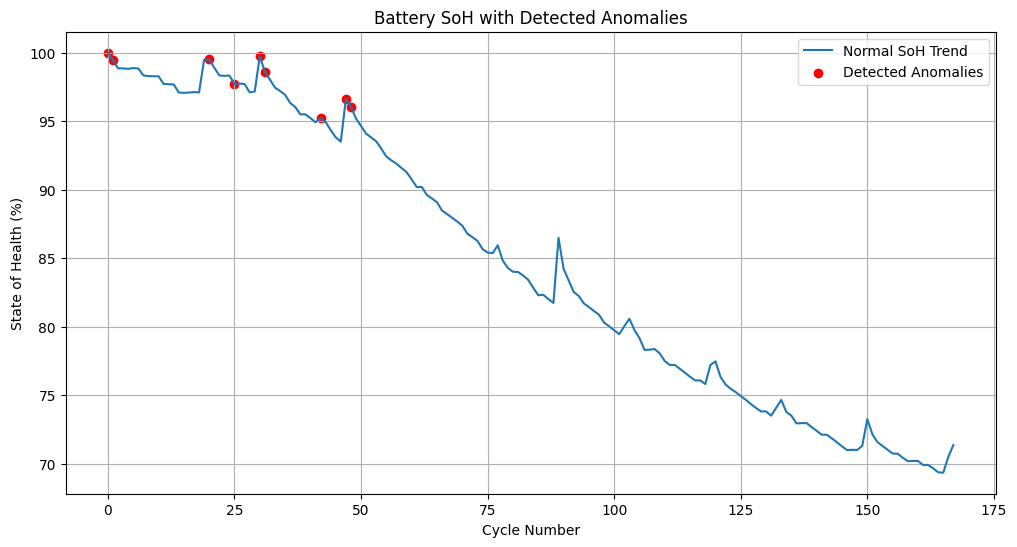

In [76]:
plt.figure(figsize=(12,6))

plt.plot(
    feature_df['cycle'],
    feature_df['soh'],
    label='Normal SoH Trend'
)

plt.scatter(
    anomalies['cycle'],
    anomalies['soh'],
    color='red',
    label='Detected Anomalies'
)

plt.xlabel("Cycle Number")
plt.ylabel("State of Health (%)")

plt.title("Battery SoH with Detected Anomalies")

plt.legend()
plt.grid(True)

plt.show()

In [77]:
feature_df.to_csv(
    "../data/processed/battery_with_anomalies.csv",
    index=False
)